## Импорт библиотек

In [2]:
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import numpy as np

## Проверка файла

In [45]:
H5_PATH = Path(r"C:\Users\Vladimir\PythonProject\RadaiML\training_v4.3.h5")

size_gb = H5_PATH.stat().st_size / (1024 ** 3)

print(f"Размер файла: {size_gb:.2f} GB")

with h5py.File(H5_PATH, "r") as file:
    print("\nКорневые объекты:")

    for name in file.keys():
        print(f"  - {name}")

Размер файла: 26.61 GB

Корневые объекты:
  - runs


In [48]:
with h5py.File(H5_PATH, "r") as file:
    runs = file["runs"]

    print(f"Количество runs: {len(runs)}")

    print("\nПервые 10 runs:")
    for name in list(runs.keys())[:10]:
        print(f"  - {name}")


Количество runs: 300

Первые 10 runs:
  - run0
  - run1
  - run2
  - run3
  - run4
  - run5
  - run6
  - run7
  - run8
  - run9


"runs" - один отдельный сеанс сбора данных, экспериментальный прогон или измерительный заезд. Тоесть, непрерывный интервал времени, в течение которого детектор регистрирует излучение при конкретных заданных условиях (например, с определенным набором источников, конфигурацией фона или траекторией движения детектора).

In [49]:
with h5py.File(H5_PATH, "r") as file:
    run0 = file["runs"]["run0"]

    print("Содержимое run0:\n")

    for name in run0.keys():
        print(f"  - {name}")

Содержимое run0:

  - detector
  - diagnostics
  - listmode
  - sources


## Назначение подгрупп внутри run
* listmode: Сырые данные поштучной регистрации квантов излучения (время задержки между импульсами dt, зарегистрированная энергия energy в кэВ, а также идентификаторы источника id и фона background_id).

* sources: Данные о радиационных источниках, присутствовавших во время сеанса — их типы, время появления, расстояние до детектора, толщина/материал экрана, отношение сигнал/шум (сигнатура SNR) и пространственные 3D-координаты (x, y, z).

* detector: Физические свойства детектора (материал, размер, ориентация) и параметры его перемещения во времени (скорость, ускорение, пройденное расстояние, широта и долгота).

* diagnostics: Показатели стабильности оборудования, включая временные колебания общей и спектральной скорости счета (count rate).

In [6]:
def print_group(group, title):
    print(f"\n{title}:")

    for name in group.keys():
        obj = group[name]

        if isinstance(obj, h5py.Dataset):
            print(
                f"  - {name:25} "
                f"shape={obj.shape}, "
                f"dtype={obj.dtype}"
            )
        elif isinstance(obj, h5py.Group):
            print(f"  - {name}/")


def main() -> None:
    with h5py.File(H5_PATH, "r") as file:
        run0 = file["runs/run0"]

        print_group(
            run0["listmode"],
            "run0/listmode"
        )

        print_group(
            run0["sources"],
            "run0/sources"
        )


if __name__ == "__main__":
    main()


run0/listmode:
  - background_id             shape=(9407758,), dtype=uint8
  - dt                        shape=(9407758,), dtype=uint16
  - energy                    shape=(9407758,), dtype=float32
  - id                        shape=(9407758,), dtype=uint16

run0/sources:
  - activity                  shape=(10,), dtype=float32
  - distance                  shape=(10,), dtype=float32
  - id                        shape=(10,), dtype=uint16
  - location_id               shape=(10,), dtype=uint16
  - shielding                 shape=(10,), dtype=uint16
  - snr/
  - standoff                  shape=(10,), dtype=float32
  - time                      shape=(10,), dtype=uint32


### Массив событий взаимодействия (Listmode) cодержит 9 407 758 индивидуально зарегистрированных гамма-квантов за весь сеанс:

* energy (float32): Зарегистрированная энергия фотона (в кэВ).

* dt (uint16): Время, прошедшее с момента предыдущей регистрации (в микросекундах).

* id (uint16): Идентификатор источника, испустившего квант.

* background_id (uint8): Идентификатор компонента естественного фона (если квант относится к фону).

### Массив параметров источников (run0/sources) описывает 10 радиоактивных источников, присутствующих в данном сеансе:

* activity (float32): Радиоактивная активность источника (интенсивность распада).

* distance (float32): Расстояние от детектора до источника.

* id (uint16): Идентификатор радионуклида (например, Cs-137, Co-60).

* location_id (uint16): Индекс пространственного размещения источника.

* shielding (uint16): Тип или толщина защиты/экранирования источника.

* snr/: Вложенная подгруппа с рассчитанным отношением сигнал/шум (пиковым и интегральным).

* standoff (float32): Прицельный параметр — минимальное расстояние сближения детектора с источником при проезде.

* time (uint32): Временная метка (в миллисекундах) прохождения или появления источника.

In [7]:
def main() -> None:
    with h5py.File(H5_PATH, "r") as file:
        run0 = file["runs/run0"]

        print("=== LISTMODE ===")

        for name in run0["listmode"].keys():
            dataset = run0["listmode"][name]

            print(
                f"{name:20} "
                f"shape={dataset.shape}, "
                f"dtype={dataset.dtype}"
            )

        print("\n=== SOURCES ===")

        for name in run0["sources"].keys():
            obj = run0["sources"][name]

            if isinstance(obj, h5py.Dataset):
                print(
                    f"{name:20} "
                    f"shape={obj.shape}, "
                    f"dtype={obj.dtype}"
                )
            else:
                print(f"{name}/")

        print("\n=== SNR ===")

        snr = run0["sources"]["snr"]

        for name in snr.keys():
            dataset = snr[name]

            print(
                f"{name:20} "
                f"shape={dataset.shape}, "
                f"dtype={dataset.dtype}"
            )

        print("\n=== FIRST SOURCE VALUES ===")

        for name in run0["sources"].keys():
            obj = run0["sources"][name]

            if isinstance(obj, h5py.Dataset):
                print(f"\n{name}:")
                print(obj[:10])

        print("\n=== SNR VALUES ===")

        for name in run0["sources"]["snr"].keys():
            dataset = run0["sources"]["snr"][name]

            print(f"\n{name}:")
            print(dataset[:10])

        print("\n=== FIRST 30 EVENTS ===")

        energy = run0["listmode/energy"]
        dt = run0["listmode/dt"]
        event_id = run0["listmode/id"]
        background_id = run0["listmode/background_id"]

        for i in range(30):
            print(
                f"{i:3} | "
                f"energy={energy[i]:8.3f} | "
                f"dt={dt[i]:5} | "
                f"id={event_id[i]:5} | "
                f"background_id={background_id[i]:3}"
            )

        print("\n=== DATASET ATTRIBUTES ===")

        for name in [
            "listmode/energy",
            "listmode/dt",
            "listmode/id",
            "listmode/background_id",
        ]:
            dataset = run0[name]

            print(f"\n{name}:")

            for key, value in dataset.attrs.items():
                print(f"  {key} = {value}")
        
if __name__ == "__main__":
    main()

=== LISTMODE ===
background_id        shape=(9407758,), dtype=uint8
dt                   shape=(9407758,), dtype=uint16
energy               shape=(9407758,), dtype=float32
id                   shape=(9407758,), dtype=uint16

=== SOURCES ===
activity             shape=(10,), dtype=float32
distance             shape=(10,), dtype=float32
id                   shape=(10,), dtype=uint16
location_id          shape=(10,), dtype=uint16
shielding            shape=(10,), dtype=uint16
snr/
standoff             shape=(10,), dtype=float32
time                 shape=(10,), dtype=uint32

=== SNR ===
integral             shape=(10,), dtype=float32
peak                 shape=(10,), dtype=float32

=== FIRST SOURCE VALUES ===

activity:
[5.2530165e+00 1.6518949e+08 1.2733434e+08 3.3790404e+07 1.8591851e+00
 2.6500750e+03 1.3143652e+07 9.2148883e+02 1.1380742e+00 3.0799318e+07]

distance:
[  363.6167  2056.5767  4964.6216  5718.6553  6253.571   9992.248
 11642.076  12467.504  13352.0205 14198.374 ]

id:
[

In [8]:
def print_attributes(obj, title):
    print(f"\n=== {title} ===")

    if len(obj.attrs) == 0:
        print("Атрибутов нет.")
        return

    for key, value in obj.attrs.items():
        print(f"{key} = {value}")


def main() -> None:
    with h5py.File(H5_PATH, "r") as file:
        run0 = file["runs/run0"]

        print_attributes(file, "ROOT")
        print_attributes(file["runs"], "RUNS")
        print_attributes(run0, "RUN0")
        print_attributes(run0["listmode"], "LISTMODE")
        print_attributes(run0["sources"], "SOURCES")

        print("\n=== SOURCES/SNR ATTRIBUTES ===")
        print_attributes(run0["sources"]["snr"], "SNR")


if __name__ == "__main__":
    main()


=== ROOT ===
background_ids = [0 1 2 3 4 5 6 7]
background_names = ['Src' 'K-40' 'U' 'Th' 'Cs137_Soil' 'Pb-214' 'Bi-214' 'Cosmics']
format = 7
source_shielding_ids = [0 1 2 3 4 5 6 7]
source_shielding_names = ['None' '0.025cm_steel' '1cm_steel' '2cm_steel' '5cm_steel' '8cm_PMMA'
 '1cm_Al' '2cm_Al']
source_names = ['BKG' 'K-40_shielding_id=0' 'K-40_shielding_id=2' 'Co-57_shielding_id=0'
 'Co-57_shielding_id=2' 'Co-60_shielding_id=0' 'Co-60_shielding_id=2'
 'Cs-137_shielding_id=0' 'Cs-137_shielding_id=2' 'Ba-133_shielding_id=0'
 'Ba-133_shielding_id=2' 'Ir-192_shielding_id=0' 'Ir-192_shielding_id=2'
 'Ra-226_shielding_id=0' 'Ra-226_shielding_id=2' 'Th-232_shielding_id=0'
 'Th-232_shielding_id=2' 'Am-241_shielding_id=0' 'Am-241_shielding_id=2'
 'F-18_shielding_id=5' 'Tc-99m_shielding_id=5' 'I-131_shielding_id=5'
 'Tl-201_shielding_id=5' 'NatU-2.5kg_shielding_id=0'
 'NatU-10kg_shielding_id=0' 'NatU-25kg_shielding_id=0'
 'NatU-2.5kg_shielding_id=2' 'NatU-10kg_shielding_id=2'
 'NatU-25kg_sh

=== RUN INFO ===
Run:              run0
Start:            0.000000 s
End:              3615.809717 s
Duration:         3615.809717 s

=== SOURCES ===
source_id= 43 | time=53.000 s
source_id=  1 | time=377.001 s
source_id= 16 | time=1065.002 s
source_id= 13 | time=1218.803 s
source_id= 51 | time=1291.203 s
source_id= 65 | time=2096.505 s
source_id= 14 | time=2473.906 s
source_id= 35 | time=2665.107 s
source_id= 50 | time=2880.807 s
source_id= 22 | time=3094.608 s

=== LISTMODE ===
Number of events: 9,407,758

=== TIME CHECK ===
Duration from dt: 3615.809665 s
Duration from attribute: 3615.809717 s
Difference: -0.000052 s

=== EVENT STATISTICS ===
Total events:       9,407,758
Source events:      22,122
Background events:  9,385,636
Source fraction:    0.2351%


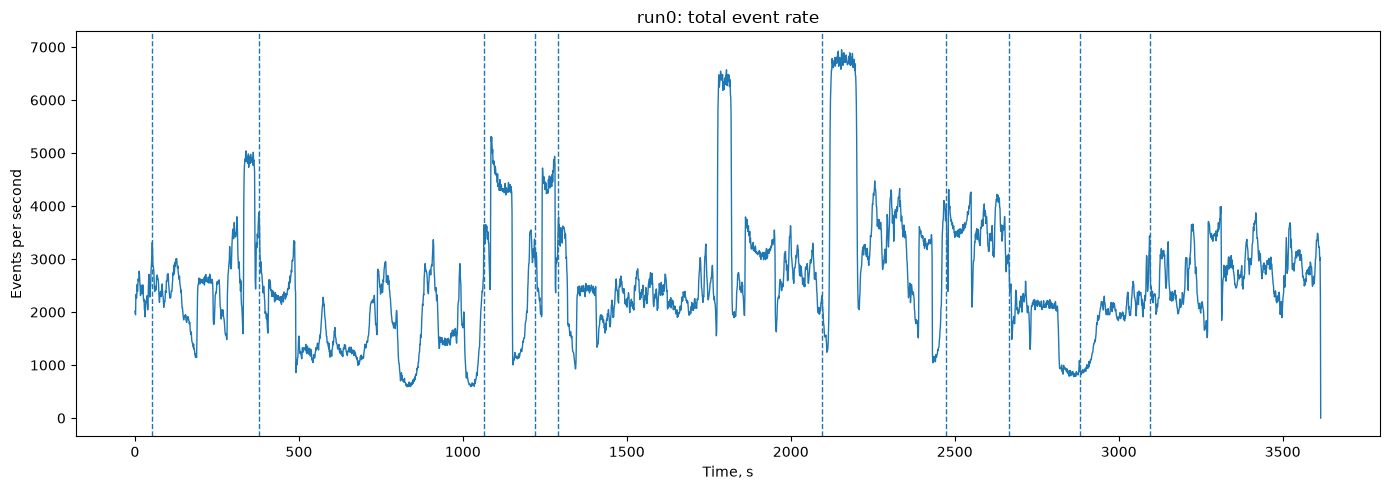

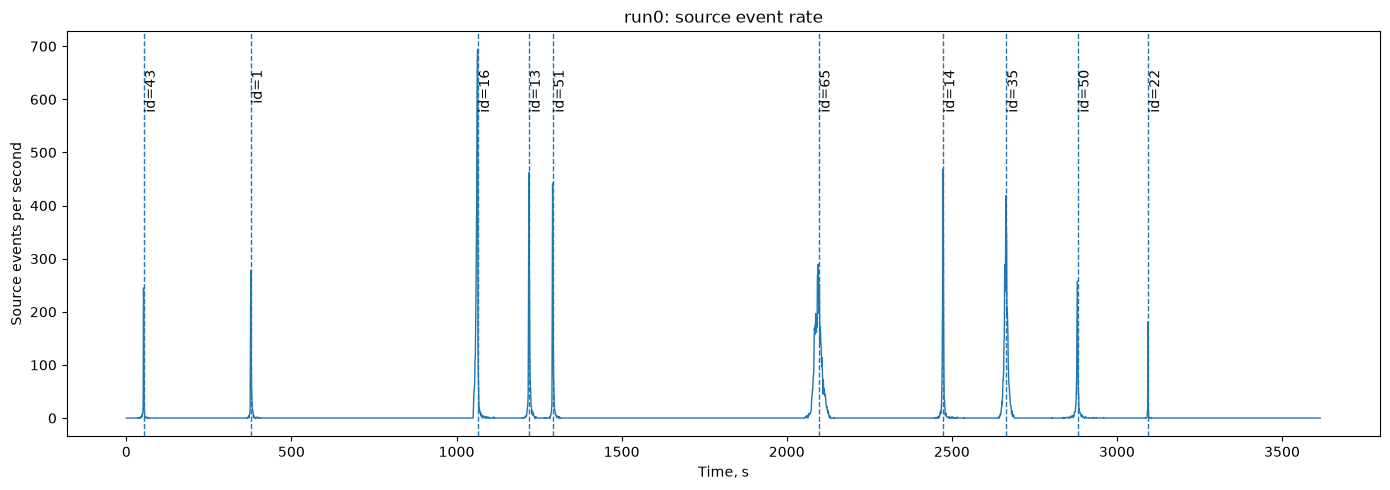

In [9]:
RUN_NAME = "run0"
CHUNK_SIZE = 500_000
BIN_SIZE_S = 1.0


def main() -> None:
    with h5py.File(H5_PATH, "r") as file:

        run = file[f"runs/{RUN_NAME}"]

        # ---------------------------------------------------------
        # 1. Информация о запуске
        # ---------------------------------------------------------

        start_timestamp = float(run.attrs["start_timestamp"])
        end_timestamp = float(run.attrs["end_timestamp"])

        print("=== RUN INFO ===")
        print(f"Run:              {RUN_NAME}")
        print(f"Start:            {start_timestamp:.6f} s")
        print(f"End:              {end_timestamp:.6f} s")
        print(f"Duration:         {end_timestamp - start_timestamp:.6f} s")

        # ---------------------------------------------------------
        # 2. Получаем данные sources
        # ---------------------------------------------------------

        source_ids = run["sources/id"][:]
        source_times_ms = run["sources/time"][:]

        print("\n=== SOURCES ===")

        for source_id, time_ms in zip(source_ids, source_times_ms):
            print(
                f"source_id={int(source_id):3d} | "
                f"time={time_ms / 1000:.3f} s"
            )

        # ---------------------------------------------------------
        # 3. Dataset listmode
        # ---------------------------------------------------------

        energy = run["listmode/energy"]
        dt = run["listmode/dt"]
        event_id = run["listmode/id"]

        n_events = energy.shape[0]

        print("\n=== LISTMODE ===")
        print(f"Number of events: {n_events:,}")

        # ---------------------------------------------------------
        # 4. Подготовка временных бинов
        # ---------------------------------------------------------

        n_bins = int(np.ceil(end_timestamp / BIN_SIZE_S)) + 1

        total_counts = np.zeros(n_bins, dtype=np.int64)
        source_counts = np.zeros(n_bins, dtype=np.int64)

        # Текущее абсолютное время события в микросекундах
        current_time_us = 0

        # ---------------------------------------------------------
        # 5. Читаем listmode кусками
        # ---------------------------------------------------------

        for start in range(0, n_events, CHUNK_SIZE):

            stop = min(start + CHUNK_SIZE, n_events)

            dt_chunk = dt[start:stop]
            id_chunk = event_id[start:stop]

            # Восстанавливаем абсолютное время событий.
            # dt хранится в микросекундах.
            event_times_us = (
                current_time_us
                + np.cumsum(dt_chunk, dtype=np.uint64)
            )

            current_time_us = int(event_times_us[-1])

            event_times_s = event_times_us / 1_000_000.0

            # Индекс временного бина
            bin_indices = np.floor(
                event_times_s / BIN_SIZE_S
            ).astype(np.int64)

            # Отбрасываем события за пределами ожидаемого run
            valid = (
                (bin_indices >= 0)
                & (bin_indices < n_bins)
            )

            bin_indices = bin_indices[valid]
            ids = id_chunk[valid]

            # Общее количество событий
            np.add.at(
                total_counts,
                bin_indices,
                1
            )

            # Source event определяется как id != 0
            source_mask = ids != 0

            np.add.at(
                source_counts,
                bin_indices[source_mask],
                1
            )

        # ---------------------------------------------------------
        # 6. Проверяем полученную временную шкалу
        # ---------------------------------------------------------

        reconstructed_duration_s = current_time_us / 1_000_000.0

        print("\n=== TIME CHECK ===")
        print(
            f"Duration from dt: {reconstructed_duration_s:.6f} s"
        )
        print(
            f"Duration from attribute: "
            f"{end_timestamp - start_timestamp:.6f} s"
        )
        print(
            f"Difference: "
            f"{reconstructed_duration_s - (end_timestamp - start_timestamp):.6f} s"
        )

        # ---------------------------------------------------------
        # 7. Статистика source/background
        # ---------------------------------------------------------

        total_events = int(total_counts.sum())
        total_source_events = int(source_counts.sum())
        total_background_events = total_events - total_source_events

        print("\n=== EVENT STATISTICS ===")
        print(f"Total events:       {total_events:,}")
        print(f"Source events:      {total_source_events:,}")
        print(f"Background events:  {total_background_events:,}")

        if total_events > 0:
            print(
                f"Source fraction:    "
                f"{100 * total_source_events / total_events:.4f}%"
            )

        # ---------------------------------------------------------
        # 8. Временная ось
        # ---------------------------------------------------------

        time_axis = np.arange(n_bins) * BIN_SIZE_S

        # ---------------------------------------------------------
        # 9. График 1 — все события
        # ---------------------------------------------------------

        plt.figure(figsize=(14, 5))

        plt.plot(
            time_axis,
            total_counts,
            linewidth=1
        )

        for time_ms in source_times_ms:
            plt.axvline(
                time_ms / 1000.0,
                linestyle="--",
                linewidth=1
            )

        plt.xlabel("Time, s")
        plt.ylabel("Events per second")
        plt.title(f"{RUN_NAME}: total event rate")

        plt.tight_layout()
        plt.show()

        # ---------------------------------------------------------
        # 10. График 2 — события от sources
        # ---------------------------------------------------------

        plt.figure(figsize=(14, 5))

        plt.plot(
            time_axis,
            source_counts,
            linewidth=1
        )

        for source_id, time_ms in zip(
            source_ids,
            source_times_ms
        ):
            plt.axvline(
                time_ms / 1000.0,
                linestyle="--",
                linewidth=1
            )

            plt.text(
                time_ms / 1000.0,
                plt.ylim()[1] * 0.9,
                f"id={int(source_id)}",
                rotation=90,
                verticalalignment="top"
            )

        plt.xlabel("Time, s")
        plt.ylabel("Source events per second")
        plt.title(f"{RUN_NAME}: source event rate")

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    main()

Всего событий в окне: 6492
Source events: 456
Background events: 6036


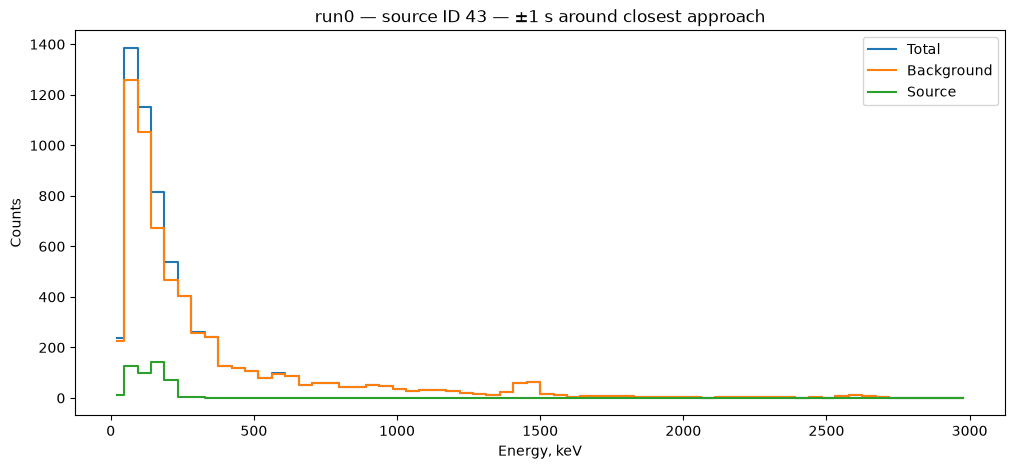

In [10]:
file = h5py.File(H5_PATH, "r")
run = file["runs/run0"]
dt = run["listmode/dt"]
energy = run["listmode/energy"]
event_id = run["listmode/id"]

event_time_s = np.cumsum(dt[:], dtype=np.uint64) / 1_000_000.0

source_id = 43
source_time = 53.0

window_start = source_time - 1.0
window_end = source_time + 1.0

mask = (
    (event_time_s >= window_start)
    & (event_time_s < window_end)
)

window_energy = energy[mask]
window_id = event_id[mask]

print("Всего событий в окне:", len(window_energy))
print("Source events:", np.sum(window_id != 0))
print("Background events:", np.sum(window_id == 0))

bins = np.linspace(0, 3000, 65)

total_hist, _ = np.histogram(
    window_energy,
    bins=bins
)

background_hist, _ = np.histogram(
    window_energy[window_id == 0],
    bins=bins
)

source_hist, _ = np.histogram(
    window_energy[window_id != 0],
    bins=bins
)

bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    total_hist,
    where="mid",
    label="Total"
)

plt.step(
    bin_centers,
    background_hist,
    where="mid",
    label="Background"
)

plt.step(
    bin_centers,
    source_hist,
    where="mid",
    label="Source"
)

plt.xlabel("Energy, keV")
plt.ylabel("Counts")
plt.title("run0 — source ID 43 — ±1 s around closest approach")
plt.legend()

plt.show()
file.close()

Total: 6492
Background: 6036
Source: 456
Source fraction: 0.07024029574861368


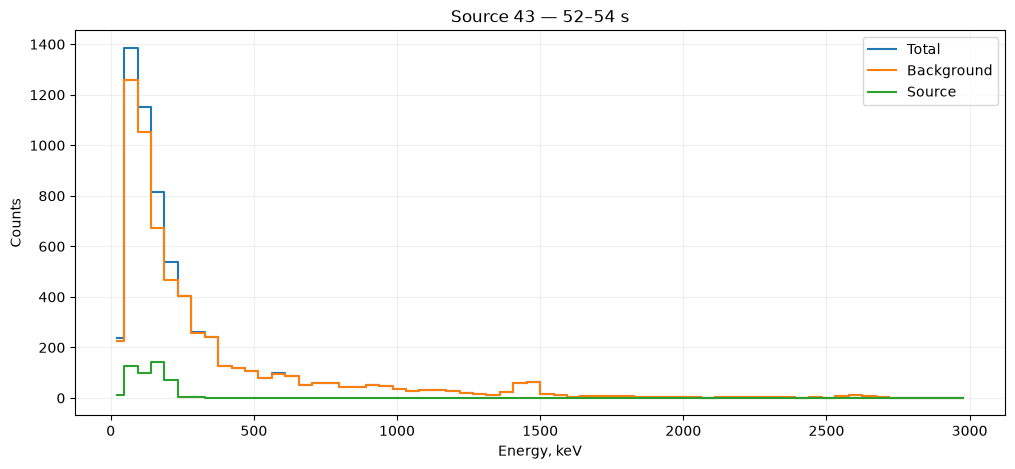

In [11]:
print("Total:", len(window_energy))
print("Background:", np.sum(window_id == 0))
print("Source:", np.sum(window_id != 0))
print("Source fraction:", np.mean(window_id != 0))

bins = np.linspace(0, 3000, 65)
bin_centers = (bins[:-1] + bins[1:]) / 2

total_hist, _ = np.histogram(window_energy, bins=bins)

background_hist, _ = np.histogram(
    window_energy[window_id == 0],
    bins=bins
)

source_hist, _ = np.histogram(
    window_energy[window_id != 0],
    bins=bins
)

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    total_hist,
    where="mid",
    label="Total"
)

plt.step(
    bin_centers,
    background_hist,
    where="mid",
    label="Background"
)

plt.step(
    bin_centers,
    source_hist,
    where="mid",
    label="Source"
)

plt.xlabel("Energy, keV")
plt.ylabel("Counts")
plt.title("Source 43 — 52–54 s")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [12]:

RUN_NAME = "run0"

CHUNK_SIZE = 500_000

WINDOW_S = 30.0


def main() -> None:

    with h5py.File(H5_PATH, "r") as file:

        run = file[f"runs/{RUN_NAME}"]

        # ---------------------------------------------------------
        # Источники
        # ---------------------------------------------------------

        source_ids = run["sources/id"][:]
        source_times = run["sources/time"][:] / 1000.0
        source_snr = run["sources/snr/peak"][:]

        # ---------------------------------------------------------
        # Listmode
        # ---------------------------------------------------------

        dt = run["listmode/dt"]
        event_id = run["listmode/id"]

        n_events = dt.shape[0]

        # Массив абсолютного времени source-событий.
        # Позже сюда запишем времена всех событий, у которых id != 0.
        source_event_times = []

        current_time_us = 0

        # ---------------------------------------------------------
        # Читаем listmode кусками
        # ---------------------------------------------------------

        for start in range(0, n_events, CHUNK_SIZE):

            stop = min(start + CHUNK_SIZE, n_events)

            dt_chunk = dt[start:stop]
            id_chunk = event_id[start:stop]

            event_times_us = (
                current_time_us
                + np.cumsum(dt_chunk, dtype=np.uint64)
            )

            current_time_us = int(event_times_us[-1])

            # Только source events
            mask = id_chunk != 0

            if np.any(mask):
                times_s = event_times_us[mask] / 1_000_000.0
                ids = id_chunk[mask]

                source_event_times.append(
                    np.column_stack((times_s, ids))
                )

        source_event_times = np.vstack(source_event_times)

        print("=== SOURCE ANALYSIS ===")
        print(f"Total source events: {len(source_event_times):,}")

        # ---------------------------------------------------------
        # Анализируем каждый источник
        # ---------------------------------------------------------

        for source_id, source_time, snr in zip(
            source_ids,
            source_times,
            source_snr,
        ):

            source_id = int(source_id)

            mask = source_event_times[:, 1] == source_id

            times = source_event_times[mask, 0]

            # Только события в ±WINDOW_S от closest approach
            local_mask = (
                (times >= source_time - WINDOW_S)
                & (times <= source_time + WINDOW_S)
            )

            local_times = times[local_mask]

            print()
            print(
                f"Source ID: {source_id:3d} | "
                f"closest approach: {source_time:8.3f} s | "
                f"SNR: {snr:6.2f}"
            )

            print(
                f"  Total source events: {len(times):6d}"
            )

            print(
                f"  Events within ±{WINDOW_S:.0f} s: "
                f"{len(local_times):6d}"
            )

            if len(times) > 0:
                print(
                    f"  First source event: "
                    f"{times.min():.3f} s"
                )

                print(
                    f"  Last source event:  "
                    f"{times.max():.3f} s"
                )


if __name__ == "__main__":
    main()

=== SOURCE ANALYSIS ===
Total source events: 22,122

Source ID:  43 | closest approach:   53.000 s | SNR:   6.04
  Total source events:    561
  Events within ±30 s:    561
  First source event: 35.815 s
  Last source event:  69.743 s

Source ID:   1 | closest approach:  377.001 s | SNR:   4.64
  Total source events:    847
  Events within ±30 s:    847
  First source event: 366.878 s
  Last source event:  406.013 s

Source ID:  16 | closest approach: 1065.002 s | SNR:  15.15
  Total source events:   3957
  Events within ±30 s:   3949
  First source event: 1051.735 s
  Last source event:  1115.783 s

Source ID:  13 | closest approach: 1218.803 s | SNR:   8.34
  Total source events:   1757
  Events within ±30 s:   1757
  First source event: 1201.703 s
  Last source event:  1241.001 s

Source ID:  51 | closest approach: 1291.203 s | SNR:   7.78
  Total source events:   1488
  Events within ±30 s:   1488
  First source event: 1266.503 s
  Last source event:  1315.011 s

Source ID:  65 | c

Всего событий в окне: 6492
Source events: 456
Background events: 6036


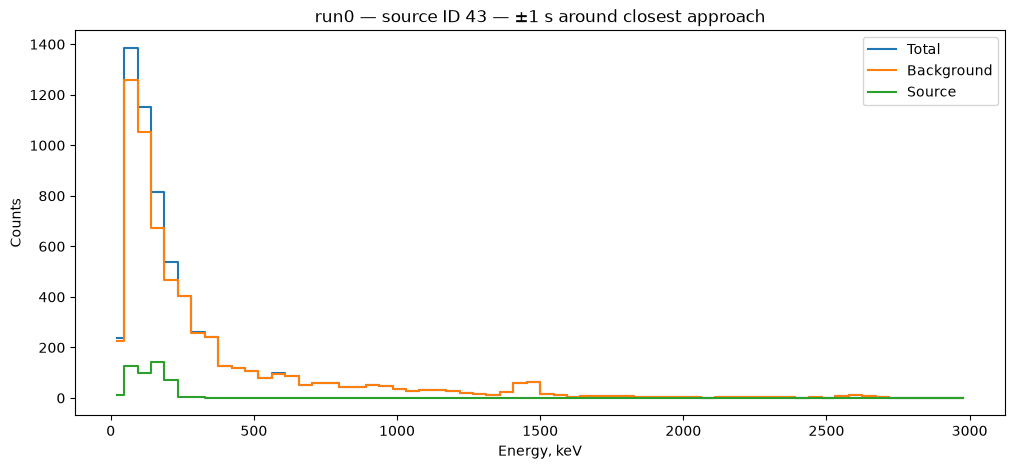

In [13]:

file = h5py.File(H5_PATH, "r")

run = file["runs/run0"]

dt = run["listmode/dt"]
energy = run["listmode/energy"]
event_id = run["listmode/id"]

event_time_s = np.cumsum(dt[:], dtype=np.uint64) / 1_000_000.0
source_id = 43
source_time = 53.0

window_start = source_time - 1.0
window_end = source_time + 1.0

mask = (
    (event_time_s >= window_start)
    & (event_time_s < window_end)
)

window_energy = energy[mask]
window_id = event_id[mask]

print("Всего событий в окне:", len(window_energy))
print("Source events:", np.sum(window_id != 0))
print("Background events:", np.sum(window_id == 0))

bins = np.linspace(0, 3000, 65)

total_hist, _ = np.histogram(
    window_energy,
    bins=bins
)

background_hist, _ = np.histogram(
    window_energy[window_id == 0],
    bins=bins
)
source_hist, _ = np.histogram(
    window_energy[window_id != 0],
    bins=bins
)
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    total_hist,
    where="mid",
    label="Total"
)

plt.step(
    bin_centers,
    background_hist,
    where="mid",
    label="Background"
)

plt.step(
    bin_centers,
    source_hist,
    where="mid",
    label="Source"
)

plt.xlabel("Energy, keV")
plt.ylabel("Counts")
plt.title("run0 — source ID 43 — ±1 s around closest approach")
plt.legend()

plt.show()
file.close()

In [14]:
print("Total:", len(window_energy))
print("Background:", np.sum(window_id == 0))
print("Source:", np.sum(window_id != 0))
print("Source fraction:", np.mean(window_id != 0))

Total: 6492
Background: 6036
Source: 456
Source fraction: 0.07024029574861368


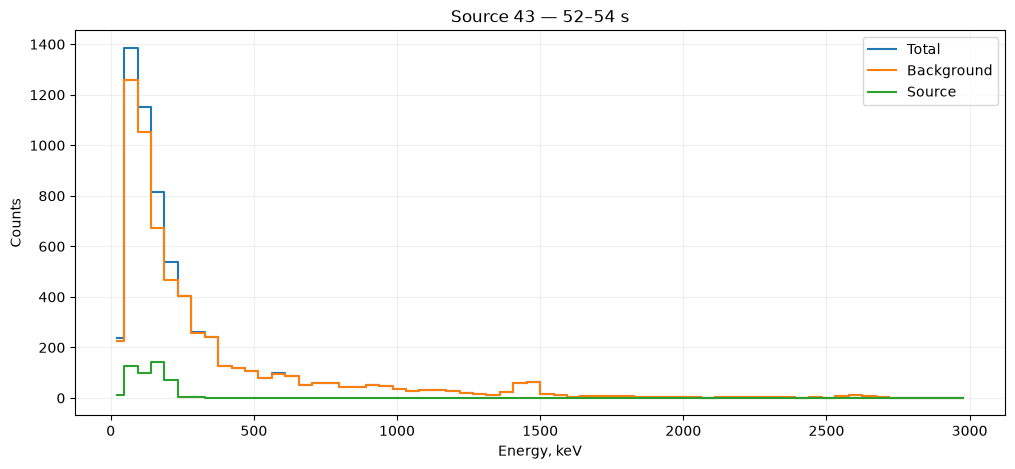

In [15]:
bins = np.linspace(0, 3000, 65)
bin_centers = (bins[:-1] + bins[1:]) / 2

total_hist, _ = np.histogram(window_energy, bins=bins)

background_hist, _ = np.histogram(
    window_energy[window_id == 0],
    bins=bins
)

source_hist, _ = np.histogram(
    window_energy[window_id != 0],
    bins=bins
)

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    total_hist,
    where="mid",
    label="Total"
)

plt.step(
    bin_centers,
    background_hist,
    where="mid",
    label="Background"
)

plt.step(
    bin_centers,
    source_hist,
    where="mid",
    label="Source"
)

plt.xlabel("Energy, keV")
plt.ylabel("Counts")
plt.title("Source 43 — 52–54 s")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Открываем training dataset
# ============================================================

H5_PATH = "training_v4.3.h5"

file = h5py.File(H5_PATH, "r")
run = file["runs/run0"]

dt = run["listmode/dt"]
energy = run["listmode/energy"]
event_id = run["listmode/id"]

print("Количество событий:", len(energy))


# ============================================================
# 2. Восстанавливаем абсолютное время событий
# ============================================================

event_time_s = (
    np.cumsum(dt[:], dtype=np.uint64)
    / 1_000_000.0
)

print(
    "Последнее время события:",
    event_time_s[-1],
    "s"
)


# ============================================================
# 3. Параметры временных окон и энергетического спектра
# ============================================================

WINDOW_SIZE = 2.0       # размер окна, секунды
STEP_SIZE = 2.0         # шаг, секунды

ENERGY_MIN = 0.0        # минимальная энергия, keV
ENERGY_MAX = 3000.0     # максимальная энергия, keV
N_BINS = 64             # количество энергетических бинов

bins = np.linspace(
    ENERGY_MIN,
    ENERGY_MAX,
    N_BINS + 1
)

print(
    "Ширина энергетического бина:",
    (ENERGY_MAX - ENERGY_MIN) / N_BINS,
    "keV"
)


# ============================================================
# 4. Создаём временные окна
# ============================================================

run_duration = float(event_time_s[-1])

window_starts = np.arange(
    0,
    run_duration - WINDOW_SIZE + 1e-9,
    STEP_SIZE
)

window_ends = window_starts + WINDOW_SIZE

print("Продолжительность run:", run_duration)
print("Количество окон:", len(window_starts))


# ============================================================
# 5. Создаём X и y
# ============================================================

X = np.zeros(
    (len(window_starts), N_BINS),
    dtype=np.float32
)

y = np.zeros(
    len(window_starts),
    dtype=np.uint8
)

source_counts = np.zeros(
    len(window_starts),
    dtype=np.int32
)

background_counts = np.zeros(
    len(window_starts),
    dtype=np.int32
)


# ============================================================
# 6. Формируем спектр каждого окна
# ============================================================

for i, (start_time, end_time) in enumerate(
    zip(window_starts, window_ends)
):

    # Индексы событий внутри временного окна
    start_idx = np.searchsorted(
        event_time_s,
        start_time,
        side="left"
    )

    end_idx = np.searchsorted(
        event_time_s,
        end_time,
        side="left"
    )

    # Энергии событий
    window_energy = energy[start_idx:end_idx]

    # ID происхождения событий
    window_ids = event_id[start_idx:end_idx]

    # --------------------------------------------------------
    # Энергетический спектр всего окна
    # --------------------------------------------------------

    spectrum, _ = np.histogram(
        window_energy,
        bins=bins
    )

    X[i] = spectrum

    # --------------------------------------------------------
    # Ground truth
    # --------------------------------------------------------

    n_source = np.sum(window_ids != 0)
    n_background = np.sum(window_ids == 0)

    source_counts[i] = n_source
    background_counts[i] = n_background

    # 1 = source присутствует
    # 0 = только background
    y[i] = 1 if n_source > 0 else 0


# ============================================================
# 7. Проверяем результат
# ============================================================

print("\n=== DATASET ===")

print("X shape:", X.shape)
print("y shape:", y.shape)

print(
    "Background windows:",
    np.sum(y == 0)
)

print(
    "Source windows:",
    np.sum(y == 1)
)


# ============================================================
# 8. Посмотрим первые положительные окна
# ============================================================

positive_indices = np.where(y == 1)[0]

print("\n=== FIRST POSITIVE WINDOWS ===")

for i in positive_indices[:20]:

    print(
        f"window={i:4d} | "
        f"time={window_starts[i]:8.2f}–"
        f"{window_ends[i]:8.2f} s | "
        f"source={source_counts[i]:4d} | "
        f"background={background_counts[i]:5d}"
    )

Количество событий: 9407758
Последнее время события: 3615.809665 s
Ширина энергетического бина: 46.875 keV
Продолжительность run: 3615.809665
Количество окон: 1807

=== DATASET ===
X shape: (1807, 64)
y shape: (1807,)
Background windows: 1568
Source windows: 239

=== FIRST POSITIVE WINDOWS ===
window=  17 | time=   34.00–   36.00 s | source=   1 | background= 4393
window=  19 | time=   38.00–   40.00 s | source=   1 | background= 4226
window=  20 | time=   40.00–   42.00 s | source=   1 | background= 4565
window=  21 | time=   42.00–   44.00 s | source=   3 | background= 5335
window=  22 | time=   44.00–   46.00 s | source=   1 | background= 4777
window=  23 | time=   46.00–   48.00 s | source=   8 | background= 4747
window=  24 | time=   48.00–   50.00 s | source=  12 | background= 5233
window=  25 | time=   50.00–   52.00 s | source=  34 | background= 5789
window=  26 | time=   52.00–   54.00 s | source= 456 | background= 6036
window=  27 | time=   54.00–   56.00 s | source=  33 | ba

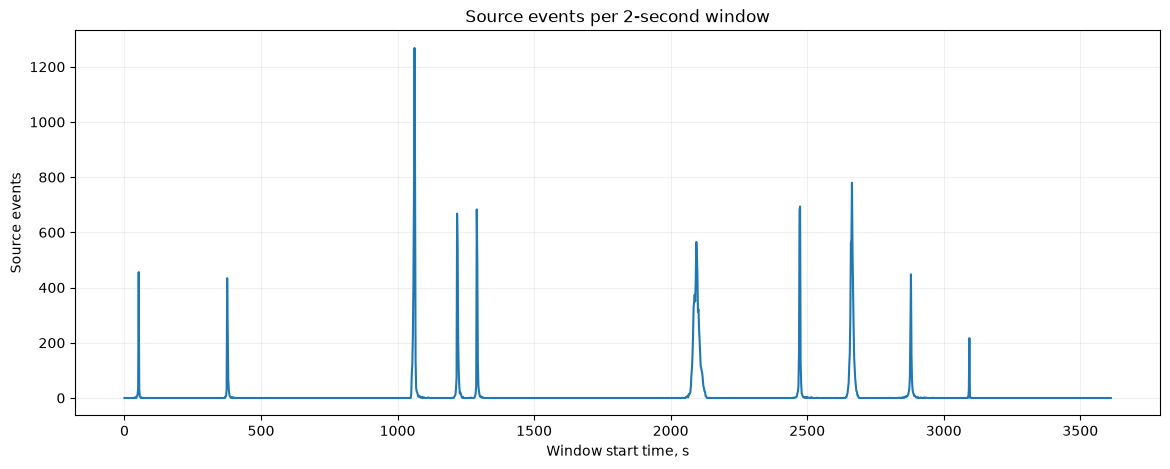

,window,start_s,end_s,total_events,source_events,background_events,source_fraction,label
17,17,34.0,36.0,4394,1,4393,0.000228,1
19,19,38.0,40.0,4227,1,4226,0.000237,1
20,20,40.0,42.0,4566,1,4565,0.000219,1
21,21,42.0,44.0,5338,3,5335,0.000562,1
22,22,44.0,46.0,4778,1,4777,0.000209,1
23,23,46.0,48.0,4755,8,4747,0.001682,1
24,24,48.0,50.0,5245,12,5233,0.002288,1
25,25,50.0,52.0,5823,34,5789,0.005839,1
26,26,52.0,54.0,6492,456,6036,0.070240,1
27,27,54.0,56.0,6008,33,5975,0.005493,1


In [17]:
import pandas as pd

dataset_info = pd.DataFrame({
    "window": np.arange(len(window_starts)),
    "start_s": window_starts,
    "end_s": window_ends,
    "total_events": source_counts + background_counts,
    "source_events": source_counts,
    "background_events": background_counts,
    "source_fraction": source_counts / (
        source_counts + background_counts
    ),
    "label": y
})

dataset_info.head(20)

dataset_info[dataset_info["label"] == 1].head(20)
dataset_info[dataset_info["label"] == 1][
    "source_events"
].describe()
dataset_info.groupby("label")[
    ["total_events", "source_events", "background_events"]
].mean()
plt.figure(figsize=(14, 5))

plt.plot(
    dataset_info["start_s"],
    dataset_info["source_events"]
)

plt.xlabel("Window start time, s")
plt.ylabel("Source events")
plt.title("Source events per 2-second window")

plt.grid(alpha=0.2)
plt.show()

dataset_info[dataset_info["label"] == 1].head(20)

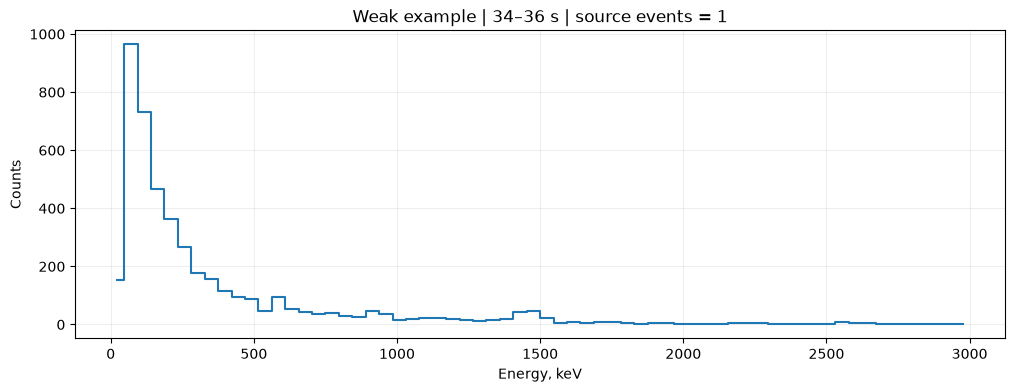

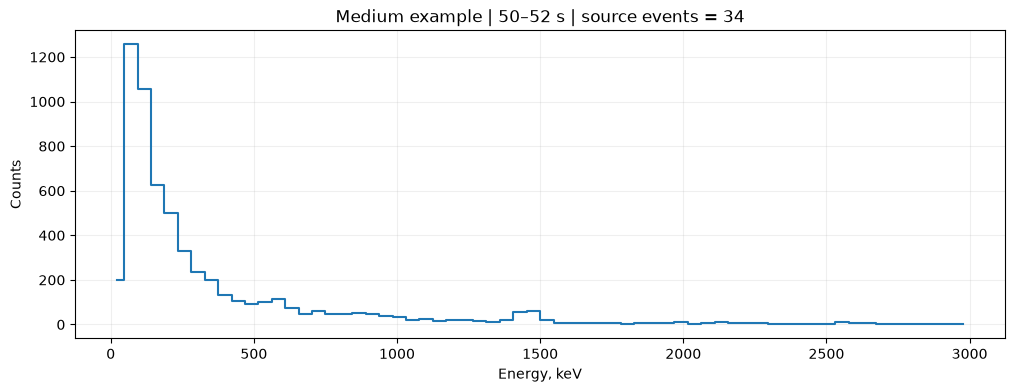

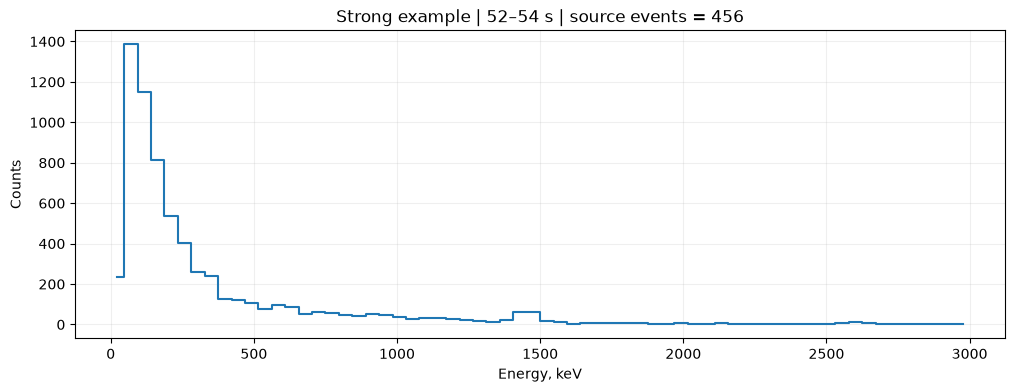

Минимум: 1
Максимум: 1268

Квантили:
[1.0000e+00 2.0000e+00 8.0000e+00 7.0500e+01 3.5060e+02 5.3880e+02
 7.6062e+02 1.2680e+03]


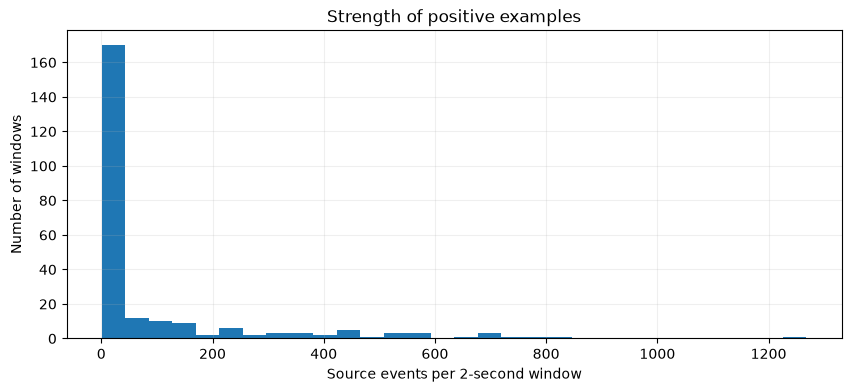

In [18]:
# Индексы интересующих окон
examples = {
    "weak": 17,      # 34-36 s, 1 source event
    "medium": 25,    # 50-52 s, 34 source events
    "strong": 26,    # 52-54 s, 456 source events
}

bin_centers = (bins[:-1] + bins[1:]) / 2

for name, idx in examples.items():

    plt.figure(figsize=(12, 4))

    plt.step(
        bin_centers,
        X[idx],
        where="mid"
    )

    plt.xlabel("Energy, keV")
    plt.ylabel("Counts")
    plt.title(
        f"{name.capitalize()} example | "
        f"{window_starts[idx]:.0f}–{window_ends[idx]:.0f} s | "
        f"source events = {source_counts[idx]}"
    )

    plt.grid(alpha=0.2)
    plt.show()

    positive_source_counts = source_counts[y == 1]

print("Минимум:", positive_source_counts.min())
print("Максимум:", positive_source_counts.max())

print("\nКвантили:")
print(
    np.percentile(
        positive_source_counts,
        [0, 25, 50, 75, 90, 95, 99, 100]
    )
)

plt.figure(figsize=(10, 4))

plt.hist(
    positive_source_counts,
    bins=30
)

plt.xlabel("Source events per 2-second window")
plt.ylabel("Number of windows")
plt.title("Strength of positive examples")

plt.grid(alpha=0.2)
plt.show()

In [19]:
background_indices = np.where(y == 0)[0]

print("Количество background окон:", len(background_indices))

print("\nПервые 10:")
for idx in background_indices[:10]:
    print(
        f"window={idx:4d} | "
        f"time={window_starts[idx]:.1f}–{window_ends[idx]:.1f} s | "
        f"events={X[idx].sum():.0f}"
    )


Количество background окон: 1568

Первые 10:
window=   0 | time=0.0–2.0 s | events=3994
window=   1 | time=2.0–4.0 s | events=4246
window=   2 | time=4.0–6.0 s | events=4599
window=   3 | time=6.0–8.0 s | events=4864
window=   4 | time=8.0–10.0 s | events=4894
window=   5 | time=10.0–12.0 s | events=5210
window=   6 | time=12.0–14.0 s | events=5348
window=   7 | time=14.0–16.0 s | events=5263
window=   8 | time=16.0–18.0 s | events=4776
window=   9 | time=18.0–20.0 s | events=4844


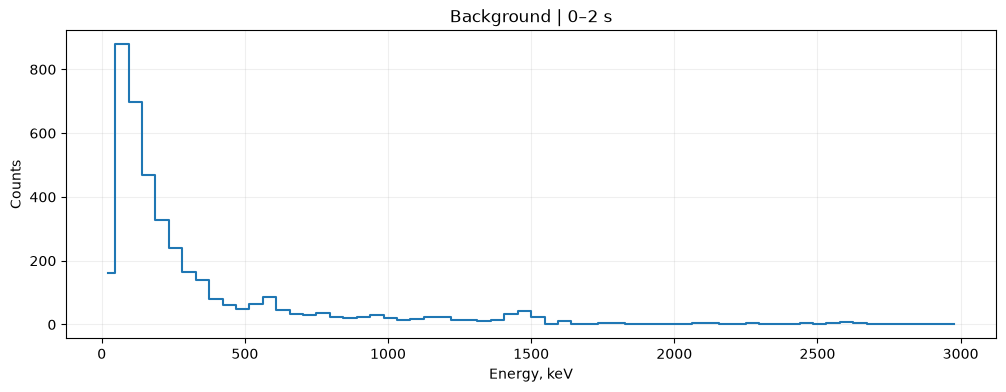

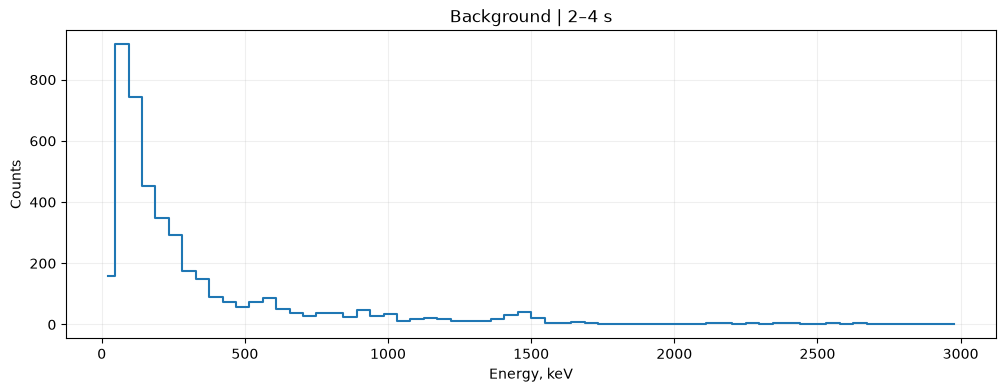

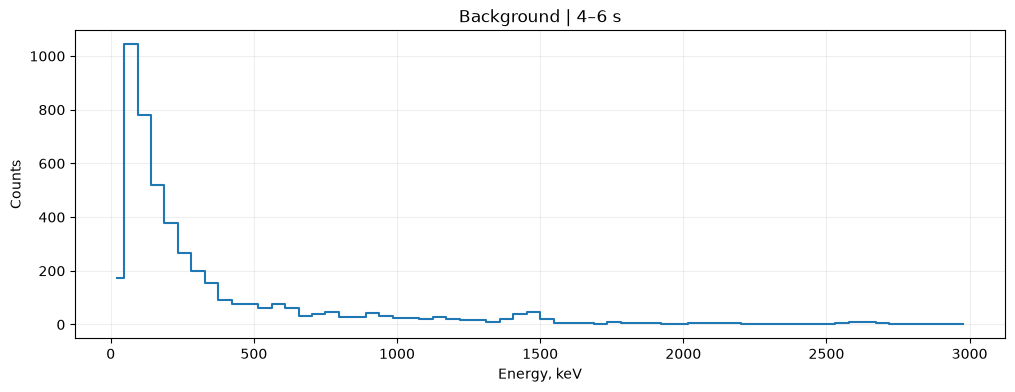

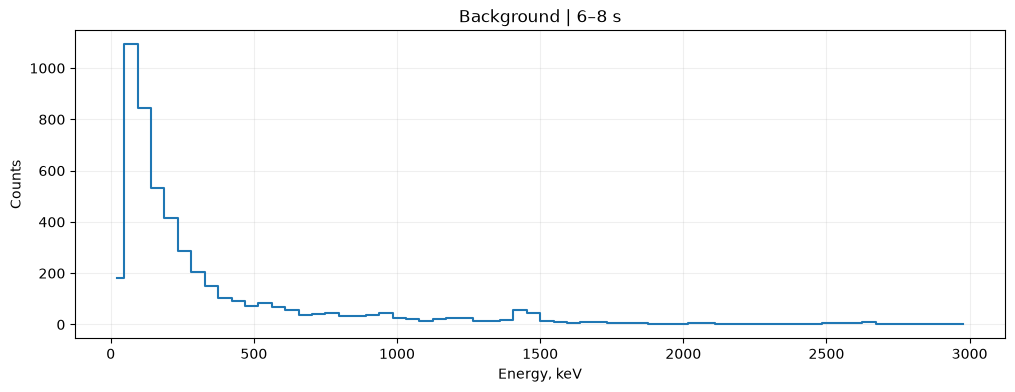

In [20]:
selected_background = background_indices[:4]

for idx in selected_background:

    plt.figure(figsize=(12, 4))

    plt.step(
        bin_centers,
        X[idx],
        where="mid"
    )

    plt.xlabel("Energy, keV")
    plt.ylabel("Counts")
    plt.title(
        f"Background | "
        f"{window_starts[idx]:.0f}–{window_ends[idx]:.0f} s"
    )

    plt.grid(alpha=0.2)
    plt.show()

In [21]:
background_X = X[y == 0]

mean_background = background_X.mean(axis=0)
std_background = background_X.std(axis=0)

print("Размер background_X:", background_X.shape)

Размер background_X: (1568, 64)


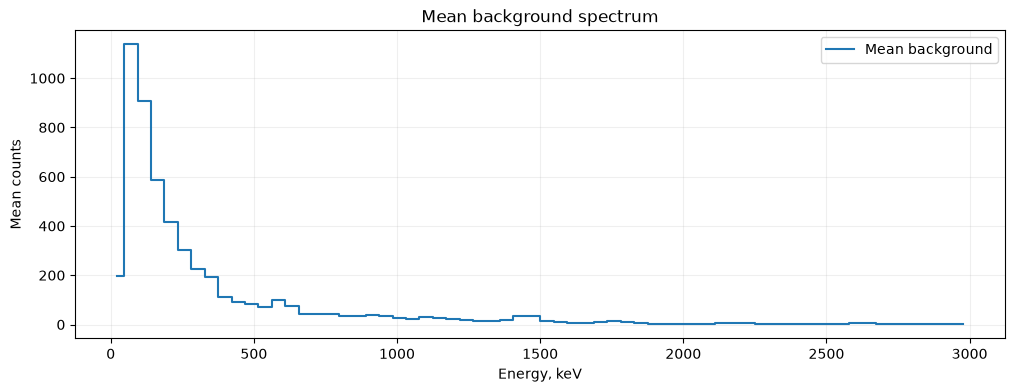

In [22]:
plt.figure(figsize=(12, 4))

plt.step(
    bin_centers,
    mean_background,
    where="mid",
    label="Mean background"
)

plt.xlabel("Energy, keV")
plt.ylabel("Mean counts")
plt.title("Mean background spectrum")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

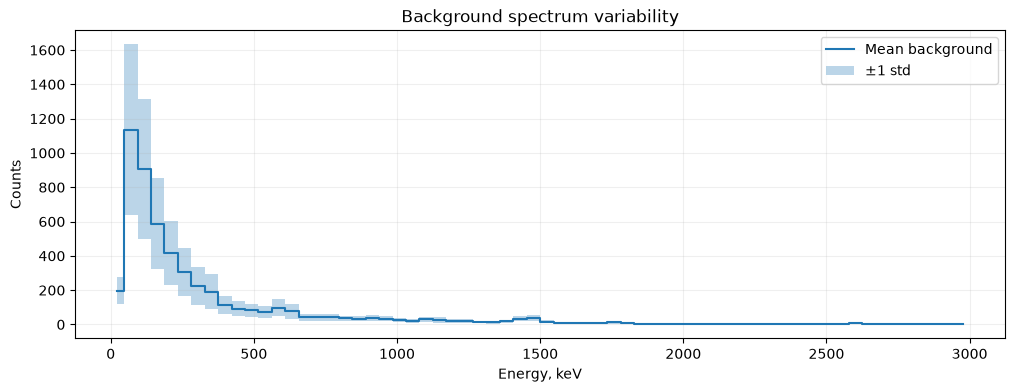

In [23]:
plt.figure(figsize=(12, 4))

plt.step(
    bin_centers,
    mean_background,
    where="mid",
    label="Mean background"
)

plt.fill_between(
    bin_centers,
    mean_background - std_background,
    mean_background + std_background,
    step="mid",
    alpha=0.3,
    label="±1 std"
)

plt.xlabel("Energy, keV")
plt.ylabel("Counts")
plt.title("Background spectrum variability")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

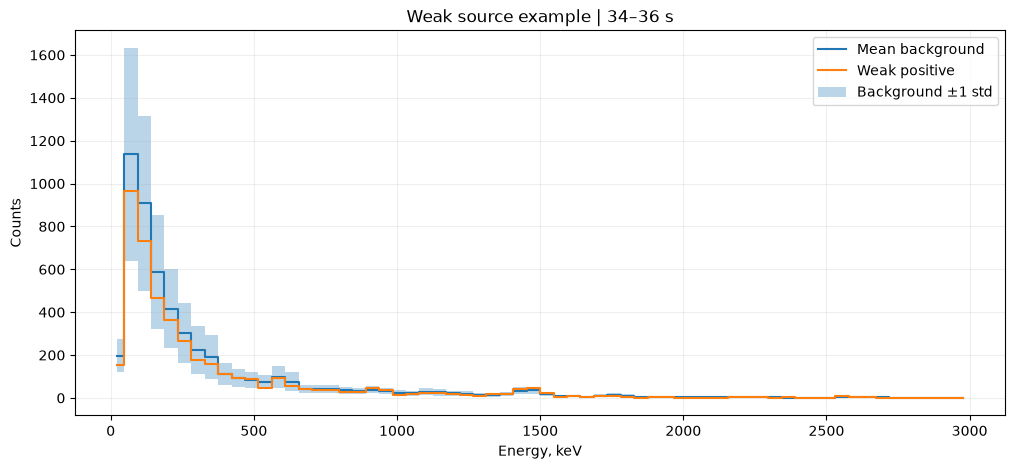

In [24]:
weak_idx = 17

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    mean_background,
    where="mid",
    label="Mean background"
)

plt.step(
    bin_centers,
    X[weak_idx],
    where="mid",
    label="Weak positive"
)

plt.fill_between(
    bin_centers,
    mean_background - std_background,
    mean_background + std_background,
    step="mid",
    alpha=0.3,
    label="Background ±1 std"
)

plt.xlabel("Energy, keV")
plt.ylabel("Counts")
plt.title(
    f"Weak source example | "
    f"{window_starts[weak_idx]:.0f}–"
    f"{window_ends[weak_idx]:.0f} s"
)

plt.legend()
plt.grid(alpha=0.2)

plt.show()

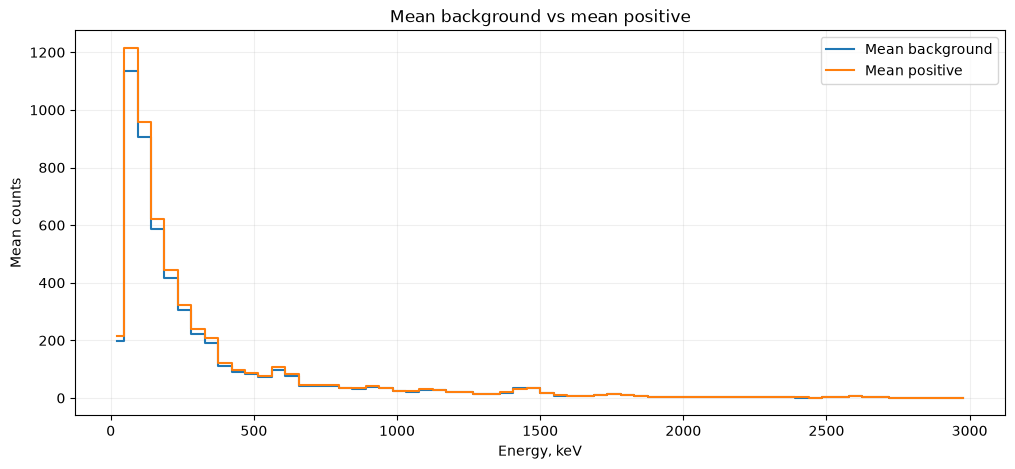

In [25]:
positive_X = X[y == 1]

mean_positive = positive_X.mean(axis=0)

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    mean_background,
    where="mid",
    label="Mean background"
)

plt.step(
    bin_centers,
    mean_positive,
    where="mid",
    label="Mean positive"
)

plt.xlabel("Energy, keV")
plt.ylabel("Mean counts")
plt.title("Mean background vs mean positive")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [32]:
def make_run_dataset(
    run,
    window_size=2.0,
    step_size=2.0,
    energy_min=0.0,
    energy_max=3000.0,
    n_bins=64,
):
    # ---------------------------------------------------------
    # Загружаем данные одного run
    # ---------------------------------------------------------

    dt = run["listmode/dt"][:]
    energy = run["listmode/energy"][:]
    event_id = run["listmode/id"][:]

    # ---------------------------------------------------------
    # Восстанавливаем абсолютное время событий
    # dt -> microseconds -> seconds
    # ---------------------------------------------------------

    event_time_s = (
        np.cumsum(dt, dtype=np.uint64)
        / 1_000_000.0
    )

    run_duration = float(event_time_s[-1])

    # ---------------------------------------------------------
    # Создаём временные окна
    # ---------------------------------------------------------

    window_starts = np.arange(
        0,
        run_duration - window_size + 1e-9,
        step_size
    )

    window_ends = window_starts + window_size

    n_windows = len(window_starts)

    # ---------------------------------------------------------
    # Номер окна для каждого события
    #
    # Сейчас используем неперекрывающиеся окна:
    # window_size = step_size
    # ---------------------------------------------------------

    if window_size != step_size:
        raise ValueError(
            "На этом этапе window_size должен быть равен step_size."
        )

    window_indices = np.floor(
        event_time_s / window_size
    ).astype(np.int64)

    valid_window = (
        (window_indices >= 0)
        & (window_indices < n_windows)
    )

    window_indices_all = window_indices[valid_window]
    event_id_all = event_id[valid_window]
    energy_all = energy[valid_window]

    # ---------------------------------------------------------
    # 1. GROUND TRUTH
    #
    # Используем ВСЕ события, независимо от энергии.
    #
    # id == 0  -> background
    # id != 0  -> source
    # ---------------------------------------------------------

    source_mask = event_id_all != 0

    source_window_indices = window_indices_all[
        source_mask
    ]

    source_counts = np.bincount(
        source_window_indices,
        minlength=n_windows
    )

    y = (
        source_counts > 0
    ).astype(np.uint8)

    # ---------------------------------------------------------
    # 2. INPUT X
    #
    # Для спектра используем только 0–3000 keV
    # ---------------------------------------------------------

    valid_energy = (
        (energy_all >= energy_min)
        & (energy_all < energy_max)
    )

    window_indices_spectrum = window_indices_all[
        valid_energy
    ]

    energy_values = energy_all[
        valid_energy
    ]

    # Номер энергетического bin
    energy_indices = np.floor(
        (energy_values - energy_min)
        / (energy_max - energy_min)
        * n_bins
    ).astype(np.int64)

    valid_bin = (
        (energy_indices >= 0)
        & (energy_indices < n_bins)
    )

    window_indices_spectrum = (
        window_indices_spectrum[valid_bin]
    )

    energy_indices = energy_indices[valid_bin]

    # ---------------------------------------------------------
    # Формируем матрицу X
    # ---------------------------------------------------------

    flat_indices = (
        window_indices_spectrum * n_bins
        + energy_indices
    )

    X = np.bincount(
        flat_indices,
        minlength=n_windows * n_bins
    ).reshape(
        n_windows,
        n_bins
    ).astype(np.float32)

    # ---------------------------------------------------------
    # 3. Статистика окна
    #
    # total_counts берём из ВСЕХ событий,
    # а не только из 0–3000 keV.
    # ---------------------------------------------------------

    total_counts = np.bincount(
        window_indices_all,
        minlength=n_windows
    )

    background_counts = (
        total_counts - source_counts
    )

    return (
        X,
        y,
        window_starts,
        source_counts,
        background_counts,
    )

In [33]:
run0 = file["runs/run0"]

X_test, y_test, window_starts_test, source_counts_test, background_counts_test = (
    make_run_dataset(run0)
)

In [34]:
print("X:", X_test.shape)
print("y:", y_test.shape)

print(
    "Background windows:",
    np.sum(y_test == 0)
)

print(
    "Source windows:",
    np.sum(y_test == 1)
)

print(
    "Total source events:",
    source_counts_test.sum()
)

X: (1807, 64)
y: (1807,)
Background windows: 1568
Source windows: 239
Total source events: 22122


In [35]:
print(
    "Максимальное различие X:",
    np.max(np.abs(X - X_test))
)

Максимальное различие X: 0.0


In [36]:
print(
    "Различие y:",
    np.sum(y != y_test)
)

Различие y: 0


In [37]:
for run_number in range(3):

    run = file[f"runs/run{run_number}"]

    (
        X_run,
        y_run,
        window_starts_run,
        source_counts_run,
        background_counts_run,
    ) = make_run_dataset(run)

    print(
        f"run{run_number}: "
        f"windows={len(y_run)}, "
        f"positive={np.sum(y_run == 1)}, "
        f"negative={np.sum(y_run == 0)}, "
        f"source_events={source_counts_run.sum()}"
    )

run0: windows=1807, positive=239, negative=1568, source_events=22122
run1: windows=1801, positive=257, negative=1544, source_events=23067
run2: windows=1806, positive=223, negative=1583, source_events=19403


In [38]:
print(
    "Различий в source_counts:",
    np.sum(source_counts != source_counts_test)
)

print(
    "Различий в background_counts:",
    np.sum(background_counts != background_counts_test)
)

Различий в source_counts: 0
Различий в background_counts: 0


# ОБУЧЕНИЕ МОДЕЛИ

In [39]:
import h5py
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 1. Функция формирования X и y для одного run
# ============================================================

def make_run_dataset(
    run,
    window_size=2.0,
    step_size=2.0,
    energy_min=0.0,
    energy_max=3000.0,
    n_bins=64,
):
    # --------------------------------------------------------
    # Загружаем данные одного run
    # --------------------------------------------------------

    dt = run["listmode/dt"][:]
    energy = run["listmode/energy"][:]
    event_id = run["listmode/id"][:]

    # --------------------------------------------------------
    # Восстанавливаем абсолютное время событий
    #
    # dt хранится в микросекундах
    # --------------------------------------------------------

    event_time_s = (
        np.cumsum(dt, dtype=np.uint64)
        / 1_000_000.0
    )

    run_duration = float(event_time_s[-1])

    # --------------------------------------------------------
    # Создаём временные окна
    # --------------------------------------------------------

    if window_size != step_size:
        raise ValueError(
            "Сейчас функция поддерживает только "
            "неперекрывающиеся окна: "
            "window_size == step_size"
        )

    window_starts = np.arange(
        0,
        run_duration - window_size + 1e-9,
        step_size,
    )

    window_ends = window_starts + window_size

    n_windows = len(window_starts)

    # --------------------------------------------------------
    # Для каждого события определяем номер временного окна
    # --------------------------------------------------------

    window_indices = np.floor(
        event_time_s / window_size
    ).astype(np.int64)

    valid_window = (
        (window_indices >= 0)
        & (window_indices < n_windows)
    )

    window_indices = window_indices[valid_window]
    event_id = event_id[valid_window]
    energy = energy[valid_window]

    # ========================================================
    # 2. Формируем y
    #
    # Используем ВСЕ события, независимо от их энергии
    #
    # id == 0  -> background
    # id != 0  -> source
    # ========================================================

    source_mask = event_id != 0

    source_window_indices = window_indices[source_mask]

    source_counts = np.bincount(
        source_window_indices,
        minlength=n_windows,
    )

    y = (
        source_counts > 0
    ).astype(np.uint8)

    # ========================================================
    # 3. Формируем X
    #
    # X = энергетический спектр окна
    #
    # Используем диапазон 0–3000 keV
    # ========================================================

    valid_energy = (
        (energy >= energy_min)
        & (energy < energy_max)
    )

    window_indices_spectrum = (
        window_indices[valid_energy]
    )

    energy_values = energy[valid_energy]

    # Номер энергетического bin
    energy_indices = np.floor(
        (energy_values - energy_min)
        / (energy_max - energy_min)
        * n_bins
    ).astype(np.int64)

    valid_bin = (
        (energy_indices >= 0)
        & (energy_indices < n_bins)
    )

    window_indices_spectrum = (
        window_indices_spectrum[valid_bin]
    )

    energy_indices = energy_indices[valid_bin]

    # --------------------------------------------------------
    # Быстро формируем все спектры через np.bincount
    # --------------------------------------------------------

    flat_indices = (
        window_indices_spectrum * n_bins
        + energy_indices
    )

    X = np.bincount(
        flat_indices,
        minlength=n_windows * n_bins,
    ).reshape(
        n_windows,
        n_bins,
    ).astype(np.float32)

    # ========================================================
    # 4. Дополнительная статистика
    # ========================================================

    total_counts = np.bincount(
        window_indices,
        minlength=n_windows,
    )

    background_counts = (
        total_counts - source_counts
    )

    return (
        X,
        y,
        window_starts,
        source_counts,
        background_counts,
    )


# ============================================================
# 5. Открываем HDF5
# ============================================================

H5_PATH = "training_v4.3.h5"

file = h5py.File(H5_PATH, "r")


# ============================================================
# 6. Формируем TRAIN из run0
# ============================================================

print("=" * 60)
print("RUN0 -> TRAIN")
print("=" * 60)

(
    X_train,
    y_train,
    train_window_starts,
    train_source_counts,
    train_background_counts,
) = make_run_dataset(
    file["runs/run0"]
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Positive:", np.sum(y_train == 1))
print("Negative:", np.sum(y_train == 0))
print("Source events:", train_source_counts.sum())


# ============================================================
# 7. Формируем TEST из run1
# ============================================================

print("\n" + "=" * 60)
print("RUN1 -> TEST")
print("=" * 60)

(
    X_test1,
    y_test1,
    test1_window_starts,
    test1_source_counts,
    test1_background_counts,
) = make_run_dataset(
    file["runs/run1"]
)

print("X_test1 shape:", X_test1.shape)
print("y_test1 shape:", y_test1.shape)
print("Positive:", np.sum(y_test1 == 1))
print("Negative:", np.sum(y_test1 == 0))
print("Source events:", test1_source_counts.sum())


# ============================================================
# 8. Формируем TEST из run2
# ============================================================

print("\n" + "=" * 60)
print("RUN2 -> TEST")
print("=" * 60)

(
    X_test2,
    y_test2,
    test2_window_starts,
    test2_source_counts,
    test2_background_counts,
) = make_run_dataset(
    file["runs/run2"]
)

print("X_test2 shape:", X_test2.shape)
print("y_test2 shape:", y_test2.shape)
print("Positive:", np.sum(y_test2 == 1))
print("Negative:", np.sum(y_test2 == 0))
print("Source events:", test2_source_counts.sum())


# ============================================================
# 9. Создаём Logistic Regression
# ============================================================

model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])


# ============================================================
# 10. ОБУЧЕНИЕ ТОЛЬКО НА RUN0
# ============================================================

print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)

model.fit(
    X_train,
    y_train
)

print("Обучение завершено.")


# ============================================================
# 11. Оценка на RUN1
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION ON RUN1")
print("=" * 60)

y_pred1 = model.predict(X_test1)

y_prob1 = model.predict_proba(
    X_test1
)[:, 1]

print("\nClassification report:\n")

print(
    classification_report(
        y_test1,
        y_pred1,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test1,
        y_pred1,
    )
)

print(
    "\nBalanced accuracy:",
    balanced_accuracy_score(
        y_test1,
        y_pred1,
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test1,
        y_prob1,
    )
)

print(
    "Average Precision:",
    average_precision_score(
        y_test1,
        y_prob1,
    )
)


# ============================================================
# 12. Оценка на RUN2
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION ON RUN2")
print("=" * 60)

y_pred2 = model.predict(X_test2)

y_prob2 = model.predict_proba(
    X_test2
)[:, 1]

print("\nClassification report:\n")

print(
    classification_report(
        y_test2,
        y_pred2,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test2,
        y_pred2,
    )
)

print(
    "\nBalanced accuracy:",
    balanced_accuracy_score(
        y_test2,
        y_pred2,
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test2,
        y_prob2,
    )
)

print(
    "Average Precision:",
    average_precision_score(
        y_test2,
        y_prob2,
    )
)


# ============================================================
# 13. Закрываем файл
# ============================================================

file.close()

print("\n" + "=" * 60)
print("ГОТОВО")
print("=" * 60)

RUN0 -> TRAIN
X_train shape: (1807, 64)
y_train shape: (1807,)
Positive: 239
Negative: 1568
Source events: 22122

RUN1 -> TEST
X_test1 shape: (1801, 64)
y_test1 shape: (1801,)
Positive: 257
Negative: 1544
Source events: 23067

RUN2 -> TEST
X_test2 shape: (1806, 64)
y_test2 shape: (1806,)
Positive: 223
Negative: 1583
Source events: 19403

TRAINING
Обучение завершено.

EVALUATION ON RUN1

Classification report:

              precision    recall  f1-score   support

           0     0.8762    0.4540    0.5981      1544
           1     0.1578    0.6148    0.2512       257

    accuracy                         0.4770      1801
   macro avg     0.5170    0.5344    0.4247      1801
weighted avg     0.7737    0.4770    0.5486      1801

Confusion matrix:
[[701 843]
 [ 99 158]]

Balanced accuracy: 0.5344007681296749
ROC-AUC: 0.5566268825225298
Average Precision: 0.1699813860535842

EVALUATION ON RUN2

Classification report:

              precision    recall  f1-score   support

           0 

In [40]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)

# Предсказания на тех же данных, на которых модель обучалась
y_pred_train = model.predict(X_train)

y_prob_train = model.predict_proba(X_train)[:, 1]


print("=" * 60)
print("EVALUATION ON RUN0 (TRAIN DATA)")
print("=" * 60)

print("\nClassification report:\n")

print(
    classification_report(
        y_train,
        y_pred_train,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_train,
        y_pred_train,
    )
)

print(
    "\nBalanced accuracy:",
    balanced_accuracy_score(
        y_train,
        y_pred_train,
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_train,
        y_prob_train,
    )
)

print(
    "Average Precision:",
    average_precision_score(
        y_train,
        y_prob_train,
    )
)

EVALUATION ON RUN0 (TRAIN DATA)

Classification report:

              precision    recall  f1-score   support

           0     0.9203    0.6703    0.7756      1568
           1     0.2226    0.6192    0.3274       239

    accuracy                         0.6635      1807
   macro avg     0.5714    0.6448    0.5515      1807
weighted avg     0.8280    0.6635    0.7164      1807

Confusion matrix:
[[1051  517]
 [  91  148]]

Balanced accuracy: 0.6447637370847921
ROC-AUC: 0.6996226838015541
Average Precision: 0.2747981126108918


In [41]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 1. Нормализуем спектры
# ============================================================

X_train_norm = X_train / np.maximum(
    X_train.sum(axis=1, keepdims=True),
    1
)

X_test1_norm = X_test1 / np.maximum(
    X_test1.sum(axis=1, keepdims=True),
    1
)

X_test2_norm = X_test2 / np.maximum(
    X_test2.sum(axis=1, keepdims=True),
    1
)


print("=" * 60)
print("CHECK NORMALIZATION")
print("=" * 60)

print("Сумма первого train-спектра:")
print(X_train[0].sum())

print("Сумма первого normalized train-спектра:")
print(X_train_norm[0].sum())


# ============================================================
# 2. Создаём такую же модель
# ============================================================

model_norm = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])


# ============================================================
# 3. Обучаем ТОЛЬКО на run0
# ============================================================

print("\n" + "=" * 60)
print("TRAINING ON NORMALIZED SPECTRA")
print("=" * 60)

model_norm.fit(
    X_train_norm,
    y_train
)

print("Обучение завершено.")


# ============================================================
# 4. RUN1
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION ON RUN1")
print("=" * 60)

y_pred1_norm = model_norm.predict(
    X_test1_norm
)

y_prob1_norm = model_norm.predict_proba(
    X_test1_norm
)[:, 1]


print("\nClassification report:\n")

print(
    classification_report(
        y_test1,
        y_pred1_norm,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test1,
        y_pred1_norm,
    )
)

print(
    "\nBalanced accuracy:",
    balanced_accuracy_score(
        y_test1,
        y_pred1_norm,
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test1,
        y_prob1_norm,
    )
)

print(
    "Average Precision:",
    average_precision_score(
        y_test1,
        y_prob1_norm,
    )
)


# ============================================================
# 5. RUN2
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION ON RUN2")
print("=" * 60)

y_pred2_norm = model_norm.predict(
    X_test2_norm
)

y_prob2_norm = model_norm.predict_proba(
    X_test2_norm
)[:, 1]


print("\nClassification report:\n")

print(
    classification_report(
        y_test2,
        y_pred2_norm,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")

print(
    confusion_matrix(
        y_test2,
        y_pred2_norm,
    )
)

print(
    "\nBalanced accuracy:",
    balanced_accuracy_score(
        y_test2,
        y_pred2_norm,
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test2,
        y_prob2_norm,
    )
)

print(
    "Average Precision:",
    average_precision_score(
        y_test2,
        y_prob2_norm,
    )
)

CHECK NORMALIZATION
Сумма первого train-спектра:
3994.0
Сумма первого normalized train-спектра:
0.99999994

TRAINING ON NORMALIZED SPECTRA
Обучение завершено.

EVALUATION ON RUN1

Classification report:

              precision    recall  f1-score   support

           0     0.8698    0.5149    0.6469      1544
           1     0.1556    0.5370    0.2413       257

    accuracy                         0.5180      1801
   macro avg     0.5127    0.5259    0.4441      1801
weighted avg     0.7679    0.5180    0.5890      1801

Confusion matrix:
[[795 749]
 [119 138]]

Balanced accuracy: 0.5259306768008709
ROC-AUC: 0.5410652002983811
Average Precision: 0.1573527247945159

EVALUATION ON RUN2

Classification report:

              precision    recall  f1-score   support

           0     0.8490    0.5294    0.6521      1583
           1     0.0904    0.3318    0.1420       223

    accuracy                         0.5050      1806
   macro avg     0.4697    0.4306    0.3971      1806
weight

In [42]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
)


# ============================================================
# 1. Объединяем run0 и run1 в один TRAIN
# ============================================================

X_train_01 = np.vstack([
    X_train,
    X_test1,
])

y_train_01 = np.concatenate([
    y_train,
    y_test1,
])


print("=" * 60)
print("TRAIN = RUN0 + RUN1")
print("=" * 60)

print("X_train_01 shape:", X_train_01.shape)
print("y_train_01 shape:", y_train_01.shape)

print(
    "Positive:",
    np.sum(y_train_01 == 1)
)

print(
    "Negative:",
    np.sum(y_train_01 == 0)
)


# ============================================================
# 2. Создаём новую Logistic Regression
# ============================================================

model_01 = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])


# ============================================================
# 3. Обучение
# ============================================================

print("\n" + "=" * 60)
print("TRAINING")
print("=" * 60)

model_01.fit(
    X_train_01,
    y_train_01
)

print("Обучение завершено.")


# ============================================================
# 4. Оценка на RUN2
# ============================================================

print("\n" + "=" * 60)
print("EVALUATION ON RUN2")
print("=" * 60)

y_pred_run2 = model_01.predict(
    X_test2
)

y_prob_run2 = model_01.predict_proba(
    X_test2
)[:, 1]


print("\nClassification report:\n")

print(
    classification_report(
        y_test2,
        y_pred_run2,
        digits=4,
        zero_division=0,
    )
)


print("Confusion matrix:")

cm_run2 = confusion_matrix(
    y_test2,
    y_pred_run2
)

print(cm_run2)


print(
    "\nBalanced accuracy:",
    balanced_accuracy_score(
        y_test2,
        y_pred_run2
    )
)


print(
    "ROC-AUC:",
    roc_auc_score(
        y_test2,
        y_prob_run2
    )
)


print(
    "Average Precision:",
    average_precision_score(
        y_test2,
        y_prob_run2
    )
)

TRAIN = RUN0 + RUN1
X_train_01 shape: (3608, 64)
y_train_01 shape: (3608,)
Positive: 496
Negative: 3112

TRAINING
Обучение завершено.

EVALUATION ON RUN2

Classification report:

              precision    recall  f1-score   support

           0     0.8552    0.5894    0.6978      1583
           1     0.0909    0.2915    0.1386       223

    accuracy                         0.5526      1806
   macro avg     0.4730    0.4404    0.4182      1806
weighted avg     0.7608    0.5526    0.6288      1806

Confusion matrix:
[[933 650]
 [158  65]]

Balanced accuracy: 0.44043353002331387
ROC-AUC: 0.4465126951437499
Average Precision: 0.10364008318955087


In [51]:
import h5py

H5_PATH = "training_v4.3.h5"

file = h5py.File(H5_PATH, "r")

print("Файл открыт:", file)
print("Runs:", len(file["runs"]))

Файл открыт: <HDF5 file "training_v4.3.h5" (mode r)>
Runs: 300


In [52]:
for run_number in range(3):

    run = file[f"runs/run{run_number}"]

    source_ids = run["sources/id"][:]
    source_snr = run["sources/snr/peak"][:]
    source_activity = run["sources/activity"][:]
    source_distance = run["sources/distance"][:]

    print("=" * 70)
    print(f"RUN {run_number}")
    print("=" * 70)

    for source_id, snr, activity, distance in zip(
        source_ids,
        source_snr,
        source_activity,
        source_distance,
    ):
        source_id = int(source_id)

        source_name = file.attrs["source_names"][source_id]

        print(
            f"ID={source_id:2d} | "
            f"{source_name:45s} | "
            f"SNR={snr:6.2f} | "
            f"activity={activity:12.3f} | "
            f"distance={distance:9.2f} m"
        )

RUN 0
ID=43 | HEU-25kg_shielding_id=0                       | SNR=  6.04 | activity=       5.253 | distance=   363.62 m
ID= 1 | K-40_shielding_id=0                           | SNR=  4.64 | activity=165189488.000 | distance=  2056.58 m
ID=16 | Th-232_shielding_id=2                         | SNR= 15.15 | activity=127334336.000 | distance=  4964.62 m
ID=13 | Ra-226_shielding_id=0                         | SNR=  8.34 | activity=33790404.000 | distance=  5718.66 m
ID=51 | FGPu-2kg_shielding_id=2                       | SNR=  7.78 | activity=       1.859 | distance=  6253.57 m
ID=65 | DU-1kg_shielding_id=0                         | SNR=  6.23 | activity=    2650.075 | distance=  9992.25 m
ID=14 | Ra-226_shielding_id=2                         | SNR=  8.93 | activity=13143652.000 | distance= 11642.08 m
ID=35 | LEU-2.5kg_shielding_id=0                      | SNR=  7.89 | activity=     921.489 | distance= 12467.50 m
ID=50 | FGPu-0.5kg_shielding_id=2                     | SNR=  8.27 | activity=  

In [53]:
from collections import Counter

source_ids_all = []

for run_number in range(300):

    run = file[f"runs/run{run_number}"]

    ids = run["sources/id"][:]

    source_ids_all.extend(
        ids.astype(int)
    )


counter = Counter(source_ids_all)

print("Всего source entries:", len(source_ids_all))
print("Уникальных source IDs:", len(counter))

print("\nСамые частые source IDs:")

for source_id, count in counter.most_common(20):

    source_name = file.attrs["source_names"][source_id]

    print(
        f"ID={source_id:2d} | "
        f"{source_name} | "
        f"runs/entries={count}"
    )

Всего source entries: 2700
Уникальных source IDs: 64

Самые частые source IDs:
ID=20 | Tc-99m_shielding_id=5 | runs/entries=44
ID= 1 | K-40_shielding_id=0 | runs/entries=43
ID=12 | Ir-192_shielding_id=2 | runs/entries=43
ID= 7 | Cs-137_shielding_id=0 | runs/entries=43
ID=34 | RefinedU-25kg_shielding_id=2 | runs/entries=43
ID=15 | Th-232_shielding_id=0 | runs/entries=43
ID= 2 | K-40_shielding_id=2 | runs/entries=43
ID=19 | F-18_shielding_id=5 | runs/entries=43
ID=44 | HEU-2.5kg_shielding_id=2 | runs/entries=43
ID=23 | NatU-2.5kg_shielding_id=0 | runs/entries=43
ID=36 | LEU-10kg_shielding_id=0 | runs/entries=43
ID= 3 | Co-57_shielding_id=0 | runs/entries=43
ID=41 | HEU-2.5kg_shielding_id=0 | runs/entries=43
ID=42 | HEU-10kg_shielding_id=0 | runs/entries=43
ID=47 | FGPu-0.5kg_shielding_id=0 | runs/entries=43
ID=43 | HEU-25kg_shielding_id=0 | runs/entries=42
ID=16 | Th-232_shielding_id=2 | runs/entries=42
ID=13 | Ra-226_shielding_id=0 | runs/entries=42
ID=51 | FGPu-2kg_shielding_id=2 | run

In [54]:
import numpy as np
import pandas as pd


run_statistics = []

for run_number in range(300):

    run = file[f"runs/run{run_number}"]

    source_ids = run["sources/id"][:]
    snr = run["sources/snr/peak"][:]

    run_statistics.append({
        "run_id": run_number,
        "n_sources": len(source_ids),
        "n_unique_sources": len(np.unique(source_ids)),
        "min_snr": np.min(snr),
        "max_snr": np.max(snr),
        "mean_snr": np.mean(snr),
    })


run_statistics = pd.DataFrame(run_statistics)

run_statistics.head()

,run_id,n_sources,n_unique_sources,min_snr,max_snr,mean_snr
0,0,10,10,3.642897,15.152358,7.692233
1,1,9,9,2.813011,11.869143,7.554987
2,2,8,8,3.195985,9.552225,6.312366
3,3,11,9,2.634888,17.093149,8.703742
4,4,10,9,5.470112,19.056900,9.404330


In [55]:
run_statistics.describe()

,run_id,n_sources,n_unique_sources,min_snr,max_snr,mean_snr
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,149.500000,9.000000,8.493333,3.386749,14.370564,7.863939
std,86.746758,1.947471,1.844260,1.314990,3.802392,1.261616
min,0.000000,1.000000,1.000000,1.538318,5.612846,4.561477
25%,74.750000,8.000000,7.750000,2.462207,10.715281,7.032808
50%,149.500000,9.000000,9.000000,2.811193,14.151420,7.789896
75%,224.250000,10.000000,10.000000,4.361879,17.686051,8.575182
max,299.000000,14.000000,13.000000,8.167565,21.532131,11.990919


In [56]:
run_statistics[
    [
        "n_sources",
        "n_unique_sources",
        "min_snr",
        "max_snr",
        "mean_snr",
    ]
].describe()

,n_sources,n_unique_sources,min_snr,max_snr,mean_snr
count,300.000000,300.000000,300.000000,300.000000,300.000000
mean,9.000000,8.493333,3.386749,14.370564,7.863939
std,1.947471,1.844260,1.314990,3.802392,1.261616
min,1.000000,1.000000,1.538318,5.612846,4.561477
25%,8.000000,7.750000,2.462207,10.715281,7.032808
50%,9.000000,9.000000,2.811193,14.151420,7.789896
75%,10.000000,10.000000,4.361879,17.686051,8.575182
max,14.000000,13.000000,8.167565,21.532131,11.990919


In [57]:
print(
    "Минимальный max SNR:",
    run_statistics["max_snr"].min()
)

print(
    "Максимальный max SNR:",
    run_statistics["max_snr"].max()
)

print(
    "Средний max SNR:",
    run_statistics["max_snr"].mean()
)

Минимальный max SNR: 5.6128464
Максимальный max SNR: 21.532131
Средний max SNR: 14.370564


In [58]:
run_statistics[
    run_statistics["run_id"].isin([0, 1, 2])
]

,run_id,n_sources,n_unique_sources,min_snr,max_snr,mean_snr
0,0,10,10,3.642897,15.152358,7.692233
1,1,9,9,2.813011,11.869143,7.554987
2,2,8,8,3.195985,9.552225,6.312366


In [59]:
background_names = file.attrs["background_names"]

print(background_names)

['Src' 'K-40' 'U' 'Th' 'Cs137_Soil' 'Pb-214' 'Bi-214' 'Cosmics']


In [60]:
background_statistics = []

for run_number in range(300):

    run = file[f"runs/run{run_number}"]

    background_id = run["listmode/background_id"][:]

    counts = np.bincount(
        background_id,
        minlength=len(background_names)
    )

    row = {
        "run_id": run_number
    }

    for background_id_value, name in enumerate(background_names):
        row[name] = counts[background_id_value]

    background_statistics.append(row)

In [61]:
background_statistics = pd.DataFrame(
    background_statistics
)

background_statistics.head()

,run_id,Src,K-40,U,Th,Cs137_Soil,Pb-214,Bi-214,Cosmics
0,0,0,1567785,5126062,2614167,2511,0,0,75958
1,1,0,1413270,4534878,3454898,3359,0,0,75605
2,2,0,1677086,5565554,3308032,6112,132822,482840,69181
3,3,0,1545527,5178787,3158119,4084,0,0,74132
4,4,0,1639560,4184694,3397056,5167,0,0,76530


In [62]:
background_statistics[
    background_statistics["run_id"].isin([0, 1, 2])
]

,run_id,Src,K-40,U,Th,Cs137_Soil,Pb-214,Bi-214,Cosmics
0,0,0,1567785,5126062,2614167,2511,0,0,75958
1,1,0,1413270,4534878,3454898,3359,0,0,75605
2,2,0,1677086,5565554,3308032,6112,132822,482840,69181


In [63]:
import numpy as np


for run_number in range(3):

    run = file[f"runs/run{run_number}"]

    background_id = run["listmode/background_id"][:]
    event_id = run["listmode/id"][:]

    values, counts = np.unique(
        background_id,
        return_counts=True
    )

    print("=" * 60)
    print(f"RUN {run_number}")
    print("=" * 60)

    print("background_id distribution:")

    for value, count in zip(values, counts):
        print(
            f"background_id={int(value):3d} : "
            f"{count:,}"
        )

    print(
        "\nbackground_id == 0:",
        np.sum(background_id == 0)
    )

    print(
        "id != 0:",
        np.sum(event_id != 0)
    )

    print(
        "Total events:",
        len(background_id)
    )

RUN 0
background_id distribution:
background_id=  1 : 1,567,785
background_id=  2 : 5,126,062
background_id=  3 : 2,614,167
background_id=  4 : 2,511
background_id=  7 : 75,958
background_id= 13 : 1,757
background_id= 14 : 1,882
background_id= 16 : 3,957
background_id= 22 : 254
background_id= 35 : 4,241
background_id= 43 : 561
background_id= 50 : 1,198
background_id= 51 : 1,488
background_id= 65 : 5,937

background_id == 0: 0
id != 0: 22122
Total events: 9407758
RUN 1
background_id distribution:
background_id=  1 : 1,413,270
background_id=  2 : 4,534,878
background_id=  3 : 3,454,898
background_id=  4 : 3,359
background_id=  7 : 75,605
background_id=  9 : 2,795
background_id= 12 : 3,717
background_id= 21 : 2,311
background_id= 29 : 2,352
background_id= 33 : 4,251
background_id= 39 : 1,940
background_id= 49 : 971
background_id= 67 : 3,940

background_id == 0: 0
id != 0: 23067
Total events: 9504287
RUN 2
background_id distribution:
background_id=  1 : 1,677,086
background_id=  2 : 5,565,

In [65]:
background_statistics = []

background_names = file.attrs["background_names"]

for run_number in range(3):

    run = file[f"runs/run{run_number}"]

    event_id = run["listmode/id"][:]
    background_id = run["listmode/background_id"][:]

    # Только background-события
    background_mask = event_id == 0

    background_ids_only = background_id[background_mask]

    counts = np.bincount(
        background_ids_only,
        minlength=len(background_names)
    )

    total_background = len(background_ids_only)

    row = {
        "run_id": run_number,
        "total_background": total_background,
    }

    for bg_id, name in enumerate(background_names):

        if bg_id == 0:
            continue

        row[name] = counts[bg_id]

    # Доли background-компонентов
    for bg_id, name in enumerate(background_names):

        if bg_id == 0:
            continue

        row[f"{name}_fraction"] = (
            counts[bg_id] / total_background
        )

    background_statistics.append(row)


background_statistics = pd.DataFrame(
    background_statistics
)

background_statistics

,run_id,total_background,K-40,U,Th,Cs137_Soil,Pb-214,Bi-214,Cosmics,K-40_fraction,U_fraction,Th_fraction,Cs137_Soil_fraction,Pb-214_fraction,Bi-214_fraction,Cosmics_fraction
0,0,9385636,1566938,5126062,2614167,2511,0,0,75958,0.166951,0.546160,0.278528,0.000268,0.000000,0.000000,0.008093
1,1,9481220,1413270,4534878,3454898,3359,0,0,74815,0.149060,0.478301,0.364394,0.000354,0.000000,0.000000,0.007891
2,2,11240758,1677086,5565554,3308032,6112,131953,482840,69181,0.149197,0.495123,0.294289,0.000544,0.011739,0.042954,0.006154


In [66]:
fraction_columns = [
    "K-40_fraction",
    "U_fraction",
    "Th_fraction",
    "Cs137_Soil_fraction",
    "Pb-214_fraction",
    "Bi-214_fraction",
    "Cosmics_fraction",
]

background_statistics[
    ["run_id"] + fraction_columns
]

,run_id,K-40_fraction,U_fraction,Th_fraction,Cs137_Soil_fraction,Pb-214_fraction,Bi-214_fraction,Cosmics_fraction
0,0,0.166951,0.546160,0.278528,0.000268,0.000000,0.000000,0.008093
1,1,0.149060,0.478301,0.364394,0.000354,0.000000,0.000000,0.007891
2,2,0.149197,0.495123,0.294289,0.000544,0.011739,0.042954,0.006154


In [67]:
background_statistics[
    background_statistics["run_id"].isin([0, 1, 2])
]

,run_id,total_background,K-40,U,Th,Cs137_Soil,Pb-214,Bi-214,Cosmics,K-40_fraction,U_fraction,Th_fraction,Cs137_Soil_fraction,Pb-214_fraction,Bi-214_fraction,Cosmics_fraction
0,0,9385636,1566938,5126062,2614167,2511,0,0,75958,0.166951,0.546160,0.278528,0.000268,0.000000,0.000000,0.008093
1,1,9481220,1413270,4534878,3454898,3359,0,0,74815,0.149060,0.478301,0.364394,0.000354,0.000000,0.000000,0.007891
2,2,11240758,1677086,5565554,3308032,6112,131953,482840,69181,0.149197,0.495123,0.294289,0.000544,0.011739,0.042954,0.006154


run0 background shape: (1568, 64)
run2 background shape: (1583, 64)


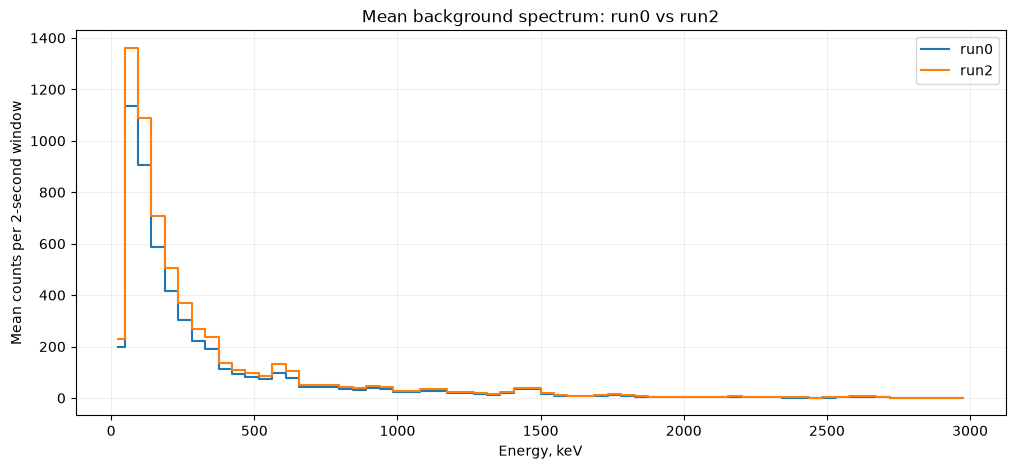

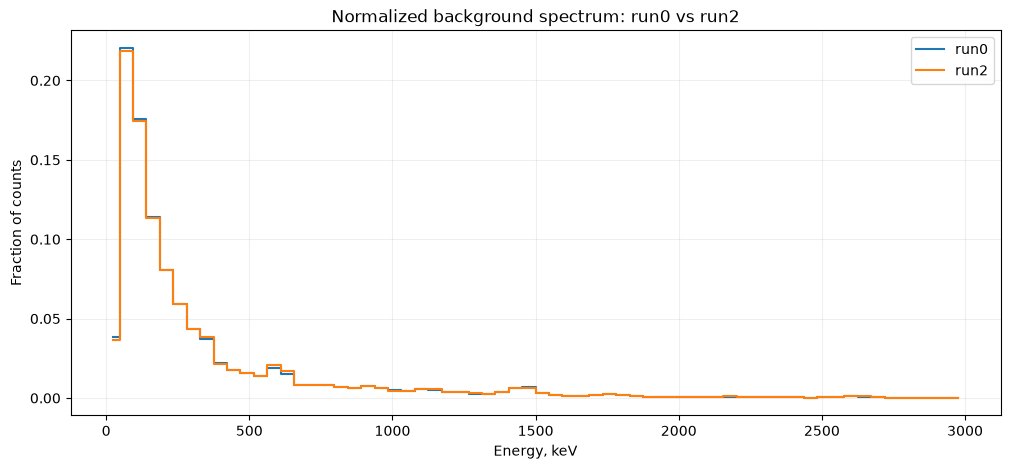

Mean absolute difference: 0.00023701788
Maximum absolute difference: 0.0019691437


In [70]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Строим X для run0 и run2
# ============================================================

X0, y0, *_ = make_run_dataset(
    file["runs/run0"]
)

X2, y2, *_ = make_run_dataset(
    file["runs/run2"]
)


# ============================================================
# 2. Оставляем только background-окна
# ============================================================

background_X0 = X0[y0 == 0]
background_X2 = X2[y2 == 0]


print("run0 background shape:", background_X0.shape)
print("run2 background shape:", background_X2.shape)


# ============================================================
# 3. Средние background-спектры
# ============================================================

mean_bg_0 = background_X0.mean(axis=0)
mean_bg_2 = background_X2.mean(axis=0)


# Центры энергетических bins
bins = np.linspace(0, 3000, 65)

bin_centers = (
    bins[:-1] + bins[1:]
) / 2


# ============================================================
# 4. График абсолютных counts
# ============================================================

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    mean_bg_0,
    where="mid",
    label="run0"
)

plt.step(
    bin_centers,
    mean_bg_2,
    where="mid",
    label="run2"
)

plt.xlabel("Energy, keV")
plt.ylabel("Mean counts per 2-second window")
plt.title("Mean background spectrum: run0 vs run2")

plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ============================================================
# 5. Нормируем каждый средний спектр
#
# Теперь сравниваем именно форму, а не общее количество
# событий.
# ============================================================

mean_bg_0_norm = (
    mean_bg_0 / mean_bg_0.sum()
)

mean_bg_2_norm = (
    mean_bg_2 / mean_bg_2.sum()
)


# ============================================================
# 6. График нормированных спектров
# ============================================================

plt.figure(figsize=(12, 5))

plt.step(
    bin_centers,
    mean_bg_0_norm,
    where="mid",
    label="run0"
)

plt.step(
    bin_centers,
    mean_bg_2_norm,
    where="mid",
    label="run2"
)

plt.xlabel("Energy, keV")
plt.ylabel("Fraction of counts")
plt.title("Normalized background spectrum: run0 vs run2")

plt.legend()
plt.grid(alpha=0.2)

plt.show()


# ============================================================
# 7. Численная оценка различия формы
# ============================================================

mean_absolute_difference = np.mean(
    np.abs(
        mean_bg_0_norm
        - mean_bg_2_norm
    )
)

max_absolute_difference = np.max(
    np.abs(
        mean_bg_0_norm
        - mean_bg_2_norm
    )
)

print(
    "Mean absolute difference:",
    mean_absolute_difference
)

print(
    "Maximum absolute difference:",
    max_absolute_difference
)